<a href="https://colab.research.google.com/github/TediBalint/AI-Jegyzetek/blob/master/Computer%20Vision/Pooling%20Technik%C3%A1k.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Pooling Technikák

Ebben a notebookban a **pooling** technikákat vizsgáljuk.

## Tartalomjegyzék

1. Pooling alapok
2. Max Pooling
3. Average Pooling
4. Global Pooling
5. Speciális pooling módszerek

## 1. Pooling alapok

### Mi a pooling?

| Tulajdonság | Leírás |
|-------------|--------|
| Downsampling | Térbeli méret csökkentése |
| Nincs tanulható paraméter | Fix művelet |
| Invariancia | Kis eltolásokra robusztus |

### Pooling céljai

1. **Dimenzió csökkentés** - kevesebb számítás
2. **Transzláció invariancia** - kis eltolások kezelése
3. **Receptive field növelése** - nagyobb kontextus

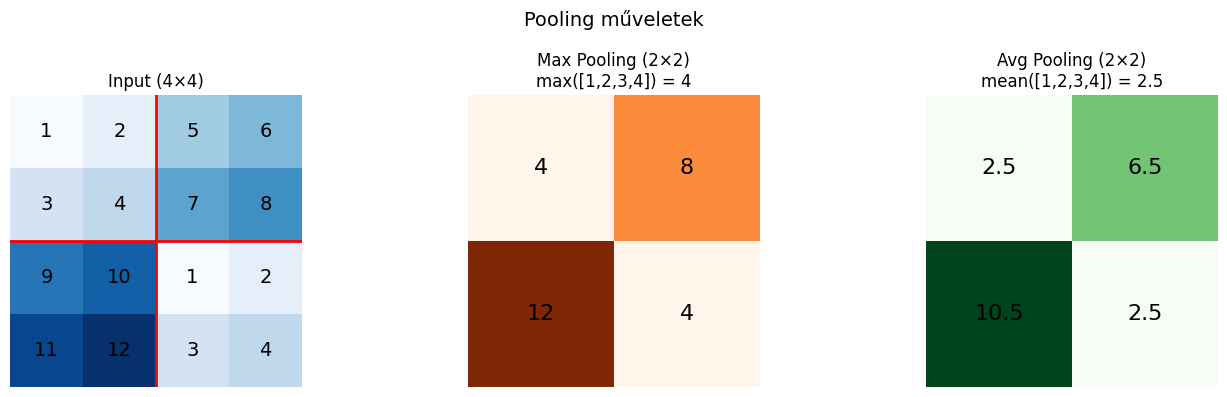

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F

np.random.seed(42)
torch.manual_seed(42)

# Pooling alapműveletek

def visualize_pooling_basics():
    """Pooling működésének vizualizálása."""
    # 4x4 input
    x = np.array([
        [1, 2, 5, 6],
        [3, 4, 7, 8],
        [9, 10, 1, 2],
        [11, 12, 3, 4]
    ], dtype=float)

    # 2x2 pooling, stride 2
    max_pool = np.array([
        [max(x[0:2, 0:2].flatten()), max(x[0:2, 2:4].flatten())],
        [max(x[2:4, 0:2].flatten()), max(x[2:4, 2:4].flatten())]
    ])

    avg_pool = np.array([
        [x[0:2, 0:2].mean(), x[0:2, 2:4].mean()],
        [x[2:4, 0:2].mean(), x[2:4, 2:4].mean()]
    ])

    fig, axes = plt.subplots(1, 3, figsize=(14, 4))

    # Input
    im0 = axes[0].imshow(x, cmap='Blues')
    for i in range(4):
        for j in range(4):
            axes[0].text(j, i, f'{x[i,j]:.0f}', ha='center', va='center', fontsize=14)
    axes[0].set_title('Input (4×4)', fontsize=12)
    axes[0].axhline(1.5, color='red', linewidth=2)
    axes[0].axvline(1.5, color='red', linewidth=2)

    # Max pooling
    im1 = axes[1].imshow(max_pool, cmap='Oranges')
    for i in range(2):
        for j in range(2):
            axes[1].text(j, i, f'{max_pool[i,j]:.0f}', ha='center', va='center', fontsize=16)
    axes[1].set_title('Max Pooling (2×2)\nmax([1,2,3,4]) = 4', fontsize=12)

    # Avg pooling
    im2 = axes[2].imshow(avg_pool, cmap='Greens')
    for i in range(2):
        for j in range(2):
            axes[2].text(j, i, f'{avg_pool[i,j]:.1f}', ha='center', va='center', fontsize=16)
    axes[2].set_title('Avg Pooling (2×2)\nmean([1,2,3,4]) = 2.5', fontsize=12)

    for ax in axes:
        ax.axis('off')

    plt.suptitle('Pooling műveletek', fontsize=14)
    plt.tight_layout()
    plt.show()

visualize_pooling_basics()

## 2. Max Pooling

### Működés

$$y_{i,j} = \max_{(m,n) \in R_{i,j}} x_{m,n}$$

### Tulajdonságok

| Előny | Hátrány |
|-------|--------|
| Domináns feature megtartása | Információ vesztés |
| Robusztus zajra | Nem differenciálható (közelítés) |
| Élek, textúrák megtartása | Kis feature-ök elveszhetnek |

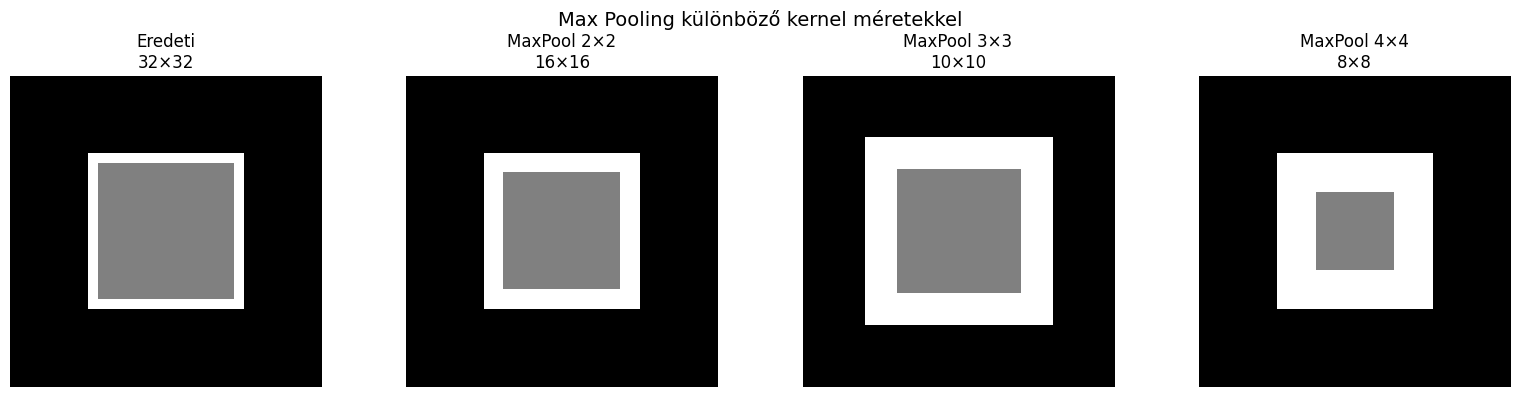

In [3]:
# Max pooling PyTorch-ban

# Szintetikus kép pattern-nel
def create_test_image():
    img = np.zeros((1, 1, 32, 32))
    # Négyzet
    img[0, 0, 8:24, 8:24] = 0.5
    # Élek
    img[0, 0, 8, 8:24] = 1.0  # felső
    img[0, 0, 23, 8:24] = 1.0  # alsó
    img[0, 0, 8:24, 8] = 1.0  # bal
    img[0, 0, 8:24, 23] = 1.0  # jobb
    return torch.FloatTensor(img)

x = create_test_image()

# Különböző kernel méretű max pooling
pool_sizes = [2, 3, 4]

fig, axes = plt.subplots(1, 4, figsize=(16, 4))

axes[0].imshow(x[0, 0], cmap='gray')
axes[0].set_title(f'Eredeti\n{x.shape[2]}×{x.shape[3]}')
axes[0].axis('off')

for ax, k in zip(axes[1:], pool_sizes):
    pool = nn.MaxPool2d(kernel_size=k, stride=k)
    out = pool(x)

    ax.imshow(out[0, 0].numpy(), cmap='gray')
    ax.set_title(f'MaxPool {k}×{k}\n{out.shape[2]}×{out.shape[3]}')
    ax.axis('off')

plt.suptitle('Max Pooling különböző kernel méretekkel', fontsize=14)
plt.tight_layout()
plt.show()

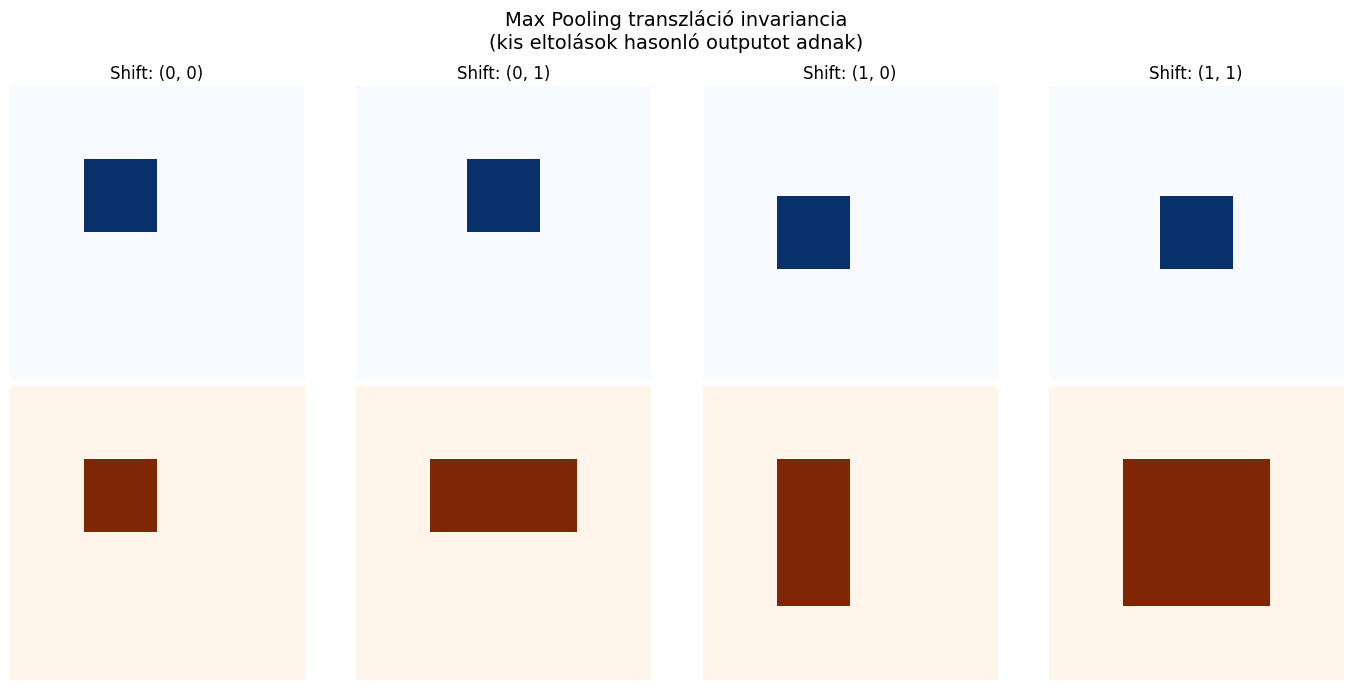

Output hasonlóság (1 = azonos):
  Shift (0, 1): 93.8%
  Shift (1, 0): 93.8%
  Shift (1, 1): 81.2%


In [4]:
# Max pooling transzláció invariancia

def test_translation_invariance():
    """Max pooling transzláció invariancia demonstráció."""
    # Alap kép egy feature-rel
    base = np.zeros((1, 1, 8, 8))
    base[0, 0, 2:4, 2:4] = 1  # Kis négyzet

    # Eltolt változatok
    shifts = [(0, 0), (0, 1), (1, 0), (1, 1)]

    pool = nn.MaxPool2d(2, stride=2)

    fig, axes = plt.subplots(2, 4, figsize=(14, 7))

    results = []
    for i, (dy, dx) in enumerate(shifts):
        shifted = np.zeros_like(base)
        shifted[0, 0, 2+dy:4+dy, 2+dx:4+dx] = 1

        x = torch.FloatTensor(shifted)
        out = pool(x)
        results.append(out[0, 0].numpy())

        # Input
        axes[0, i].imshow(shifted[0, 0], cmap='Blues')
        axes[0, i].set_title(f'Shift: ({dy}, {dx})')
        axes[0, i].axis('off')

        # Output
        axes[1, i].imshow(out[0, 0].numpy(), cmap='Oranges')
        axes[1, i].axis('off')

    # Ellenőrzés: mennyire hasonlóak az outputok
    axes[0, 0].set_ylabel('Input', fontsize=12)
    axes[1, 0].set_ylabel('MaxPool output', fontsize=12)

    plt.suptitle('Max Pooling transzláció invariancia\n(kis eltolások hasonló outputot adnak)', fontsize=14)
    plt.tight_layout()
    plt.show()

    # Hasonlóság
    print("Output hasonlóság (1 = azonos):")
    for i, (dy, dx) in enumerate(shifts[1:], 1):
        sim = (results[0] == results[i]).mean()
        print(f"  Shift ({dy}, {dx}): {sim:.1%}")

test_translation_invariance()

## 3. Average Pooling

### Működés

$$y_{i,j} = \frac{1}{|R_{i,j}|} \sum_{(m,n) \in R_{i,j}} x_{m,n}$$

### Tulajdonságok

| Előny | Hátrány |
|-------|--------|
| Simább downsampling | Élek elmosódnak |
| Minden pixel számít | Domináns feature gyengül |
| Jó textúra feladatokra | Kevésbé robusztus |

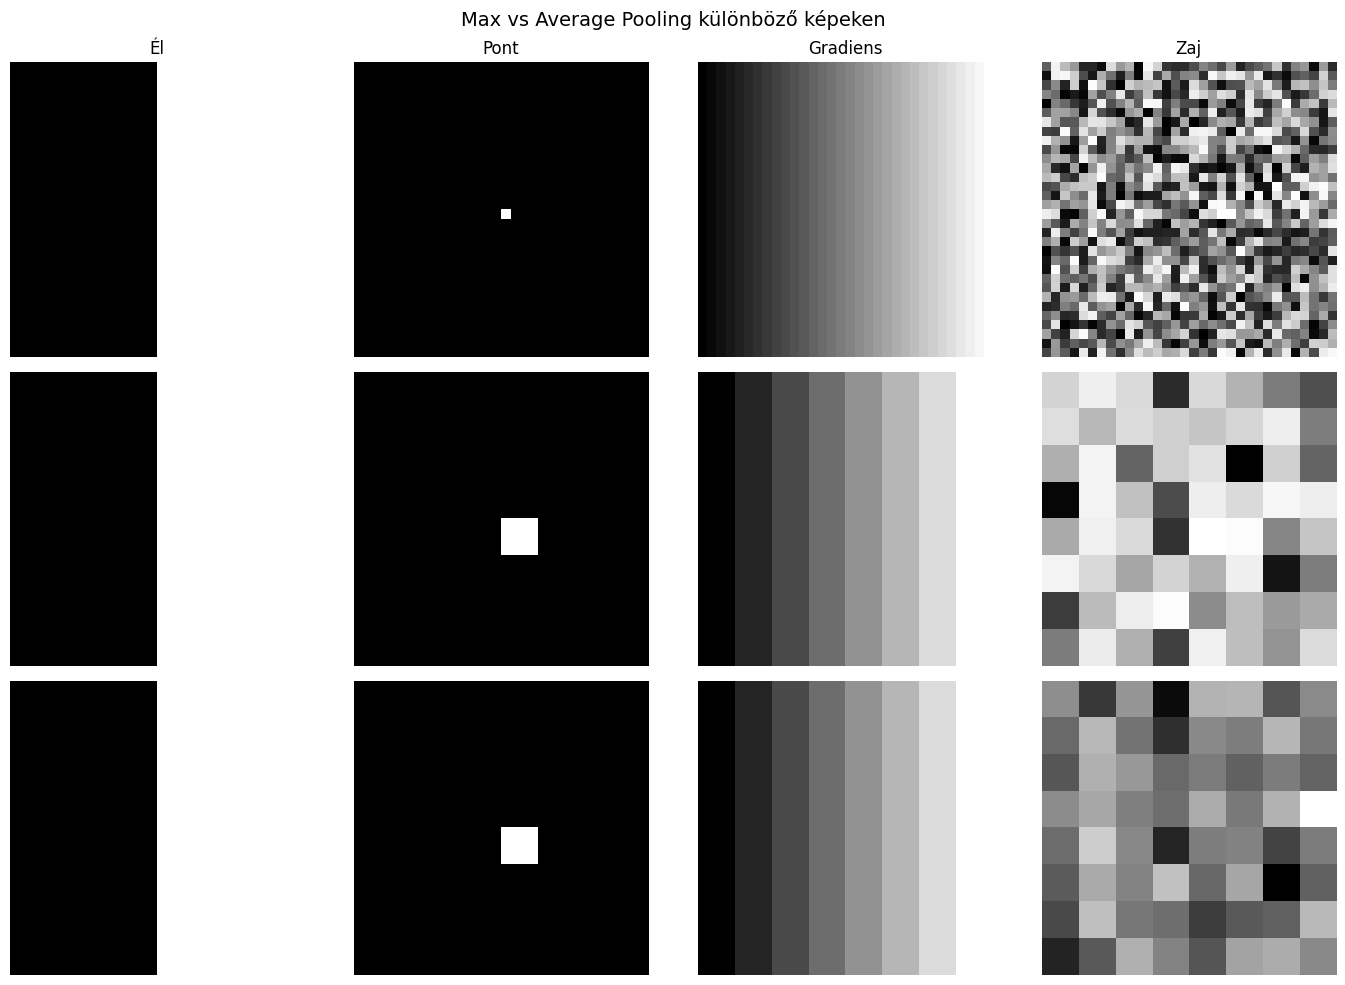

In [5]:
# Max vs Average pooling összehasonlítás

# Különböző típusú képek
def create_test_images():
    images = {}

    # Él
    edge = np.zeros((32, 32))
    edge[:, 16:] = 1
    images['Él'] = edge

    # Pont (spike)
    spike = np.zeros((32, 32))
    spike[16, 16] = 1
    images['Pont'] = spike

    # Gradiens
    gradient = np.linspace(0, 1, 32).reshape(1, -1).repeat(32, axis=0)
    images['Gradiens'] = gradient

    # Zaj
    noise = np.random.rand(32, 32)
    images['Zaj'] = noise

    return images

images = create_test_images()

max_pool = nn.MaxPool2d(4, stride=4)
avg_pool = nn.AvgPool2d(4, stride=4)

fig, axes = plt.subplots(3, 4, figsize=(14, 10))

for col, (name, img) in enumerate(images.items()):
    x = torch.FloatTensor(img).unsqueeze(0).unsqueeze(0)

    max_out = max_pool(x)[0, 0].numpy()
    avg_out = avg_pool(x)[0, 0].numpy()

    axes[0, col].imshow(img, cmap='gray')
    axes[0, col].set_title(name)
    axes[0, col].axis('off')

    axes[1, col].imshow(max_out, cmap='gray')
    axes[1, col].axis('off')

    axes[2, col].imshow(avg_out, cmap='gray')
    axes[2, col].axis('off')

axes[0, 0].set_ylabel('Eredeti', fontsize=12)
axes[1, 0].set_ylabel('Max Pool', fontsize=12)
axes[2, 0].set_ylabel('Avg Pool', fontsize=12)

plt.suptitle('Max vs Average Pooling különböző képeken', fontsize=14)
plt.tight_layout()
plt.show()

## 4. Global Pooling

### Global Average Pooling (GAP)

Teljes feature map-et egy számra redukálja:

$$y_c = \frac{1}{H \times W} \sum_{i,j} x_{c,i,j}$$

### Használat

- FC rétegek helyett a végén
- Kevesebb paraméter
- Bármilyen input méret

In [6]:
# Global pooling

# Feature maps (batch, channels, height, width)
x = torch.randn(2, 64, 14, 14)  # 2 kép, 64 feature map, 14x14

# Global Average Pooling
gap = nn.AdaptiveAvgPool2d(1)
out_gap = gap(x)  # (2, 64, 1, 1)

# Global Max Pooling
gmp = nn.AdaptiveMaxPool2d(1)
out_gmp = gmp(x)  # (2, 64, 1, 1)

print(f"Input shape: {x.shape}")
print(f"GAP output: {out_gap.shape} → squeeze → {out_gap.squeeze().shape}")
print(f"GMP output: {out_gmp.shape} → squeeze → {out_gmp.squeeze().shape}")

# Klasszikus FC vs GAP
print("\nParaméter összehasonlítás:")
fc_params = 64 * 14 * 14 * 10  # FC: flatten → 10 osztály
gap_params = 64 * 10  # GAP → FC: 64 → 10
print(f"FC (flatten + dense): {fc_params:,} paraméter")
print(f"GAP + dense: {gap_params:,} paraméter")
print(f"Csökkenés: {(1 - gap_params/fc_params)*100:.1f}%")

Input shape: torch.Size([2, 64, 14, 14])
GAP output: torch.Size([2, 64, 1, 1]) → squeeze → torch.Size([2, 64])
GMP output: torch.Size([2, 64, 1, 1]) → squeeze → torch.Size([2, 64])

Paraméter összehasonlítás:
FC (flatten + dense): 125,440 paraméter
GAP + dense: 640 paraméter
Csökkenés: 99.5%


In [7]:
# Modern CNN GAP-pel

class ModernCNN(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()

        self.features = nn.Sequential(
            # Block 1
            nn.Conv2d(1, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            # Block 2
            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            # Block 3
            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
        )

        # Global Average Pooling
        self.gap = nn.AdaptiveAvgPool2d(1)

        # Classifier
        self.classifier = nn.Linear(128, num_classes)

    def forward(self, x):
        x = self.features(x)
        x = self.gap(x)
        x = x.view(x.size(0), -1)  # Flatten
        x = self.classifier(x)
        return x

model = ModernCNN()

# Különböző input méretek!
for size in [28, 32, 64]:
    x = torch.randn(1, 1, size, size)
    out = model(x)
    print(f"Input: {size}×{size} → Output: {out.shape}")

print(f"\nParaméterek: {sum(p.numel() for p in model.parameters()):,}")

Input: 28×28 → Output: torch.Size([1, 10])
Input: 32×32 → Output: torch.Size([1, 10])
Input: 64×64 → Output: torch.Size([1, 10])

Paraméterek: 94,410


## 5. Speciális pooling módszerek

### Módszerek

| Típus | Leírás | Használat |
|-------|--------|----------|
| Fractional Max | Véletlenszerű ablak méret | Augmentáció |
| Spatial Pyramid | Több skálán pooling | Object detection |
| Stochastic | Véletlenszerű max/avg | Regularizáció |

In [8]:
# Adaptive pooling - tetszőleges output méret

x = torch.randn(1, 64, 13, 17)  # Nem szabályos méret

# Adaptive pool különböző output méretekre
output_sizes = [(7, 7), (4, 4), (1, 1)]

print(f"Input: {x.shape}")
print("\nAdaptive Average Pooling:")

for out_size in output_sizes:
    pool = nn.AdaptiveAvgPool2d(out_size)
    out = pool(x)
    print(f"  Output size {out_size} → {out.shape}")

Input: torch.Size([1, 64, 13, 17])

Adaptive Average Pooling:
  Output size (7, 7) → torch.Size([1, 64, 7, 7])
  Output size (4, 4) → torch.Size([1, 64, 4, 4])
  Output size (1, 1) → torch.Size([1, 64, 1, 1])


In [9]:
# Spatial Pyramid Pooling (SPP)

class SpatialPyramidPooling(nn.Module):
    """SPP különböző grid méretekkel."""
    def __init__(self, levels=[1, 2, 4]):
        super().__init__()
        self.levels = levels

    def forward(self, x):
        batch_size, c, h, w = x.shape
        pooled = []

        for level in self.levels:
            pool = nn.AdaptiveMaxPool2d(level)
            out = pool(x)  # (batch, c, level, level)
            pooled.append(out.view(batch_size, -1))  # Flatten

        return torch.cat(pooled, dim=1)

# Teszt
spp = SpatialPyramidPooling(levels=[1, 2, 4])

# Különböző input méretek
for size in [(14, 14), (20, 20), (32, 32)]:
    x = torch.randn(1, 64, size[0], size[1])
    out = spp(x)
    print(f"Input: 64×{size[0]}×{size[1]} → SPP output: {out.shape}")
    # 1*1*64 + 2*2*64 + 4*4*64 = 64 + 256 + 1024 = 1344

print(f"\nOutput mindig: 64*(1² + 2² + 4²) = 64*21 = {64*21}")

Input: 64×14×14 → SPP output: torch.Size([1, 1344])
Input: 64×20×20 → SPP output: torch.Size([1, 1344])
Input: 64×32×32 → SPP output: torch.Size([1, 1344])

Output mindig: 64*(1² + 2² + 4²) = 64*21 = 1344


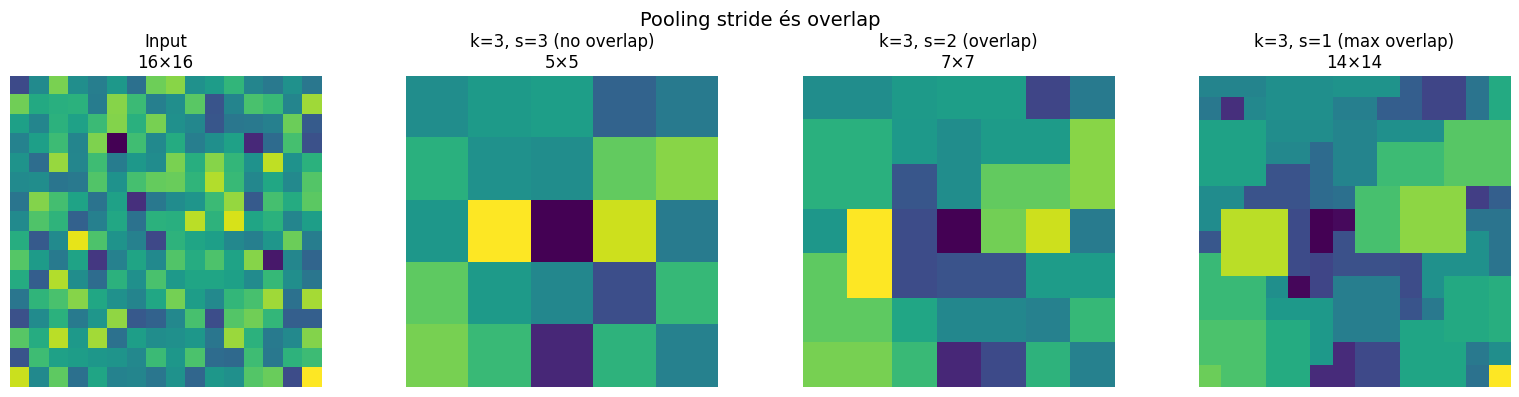

In [10]:
# Pooling stride overlap

x = torch.randn(1, 1, 16, 16)

configs = [
    {'kernel_size': 3, 'stride': 3, 'name': 'k=3, s=3 (no overlap)'},
    {'kernel_size': 3, 'stride': 2, 'name': 'k=3, s=2 (overlap)'},
    {'kernel_size': 3, 'stride': 1, 'name': 'k=3, s=1 (max overlap)'},
]

fig, axes = plt.subplots(1, 4, figsize=(16, 4))

axes[0].imshow(x[0, 0].numpy(), cmap='viridis')
axes[0].set_title(f'Input\n16×16')
axes[0].axis('off')

for ax, cfg in zip(axes[1:], configs):
    pool = nn.MaxPool2d(kernel_size=cfg['kernel_size'], stride=cfg['stride'])
    out = pool(x)

    ax.imshow(out[0, 0].numpy(), cmap='viridis')
    ax.set_title(f"{cfg['name']}\n{out.shape[2]}×{out.shape[3]}")
    ax.axis('off')

plt.suptitle('Pooling stride és overlap', fontsize=14)
plt.tight_layout()
plt.show()

## Összefoglalás

### Pooling típusok

| Típus | PyTorch | Használat |
|-------|---------|----------|
| Max Pool | `nn.MaxPool2d(k)` | Élek, textúrák |
| Avg Pool | `nn.AvgPool2d(k)` | Simább downsampling |
| Global Avg | `nn.AdaptiveAvgPool2d(1)` | Classifier előtt |
| Adaptive | `nn.AdaptiveMaxPool2d(size)` | Fix output méret |

### Best practices

1. **CNN-ben**: MaxPool2d(2, stride=2) - szabványos
2. **Végén**: Global Average Pooling FC helyett
3. **Modern**: Strided convolution pooling helyett

### Output méret

$$H_{out} = \lfloor \frac{H_{in} - K}{S} \rfloor + 1$$